In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

train = pd.read_csv("/content/drive/MyDrive/M6_assignment/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/M6_assignment/sign_mnist_test.csv")

print(train.shape)
print(test.shape)

(27455, 785)
(7172, 785)


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print (tf.__version__)


2.19.0


In [ ]:
x_train_full = train.drop('label', axis = 1).values
y_train_full = train['label'].values

x_test = test.drop('label', axis = 1).values
y_test = test['label'].values

x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_full, y_train_full,
    test_size = 0.2, random_state = 42, stratify = y_train_full)

num_classes = 25
y_train = to_categorical(y_train, num_classes)
y_valid = to_categorical(y_valid, num_classes)
y_test = to_categorical(y_test, num_classes)

class_names = [chr (i) for i in range (65,91) if chr(i) not in ('J', 'Z')]

print(f"Train: {x_train.shape[0]} | valid: {x_valid.shape[0]} | test: {x_test.shape[0]}")
print("Classes:", class_names)

Train: 21964 | valid: 5491 | test: 7172
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


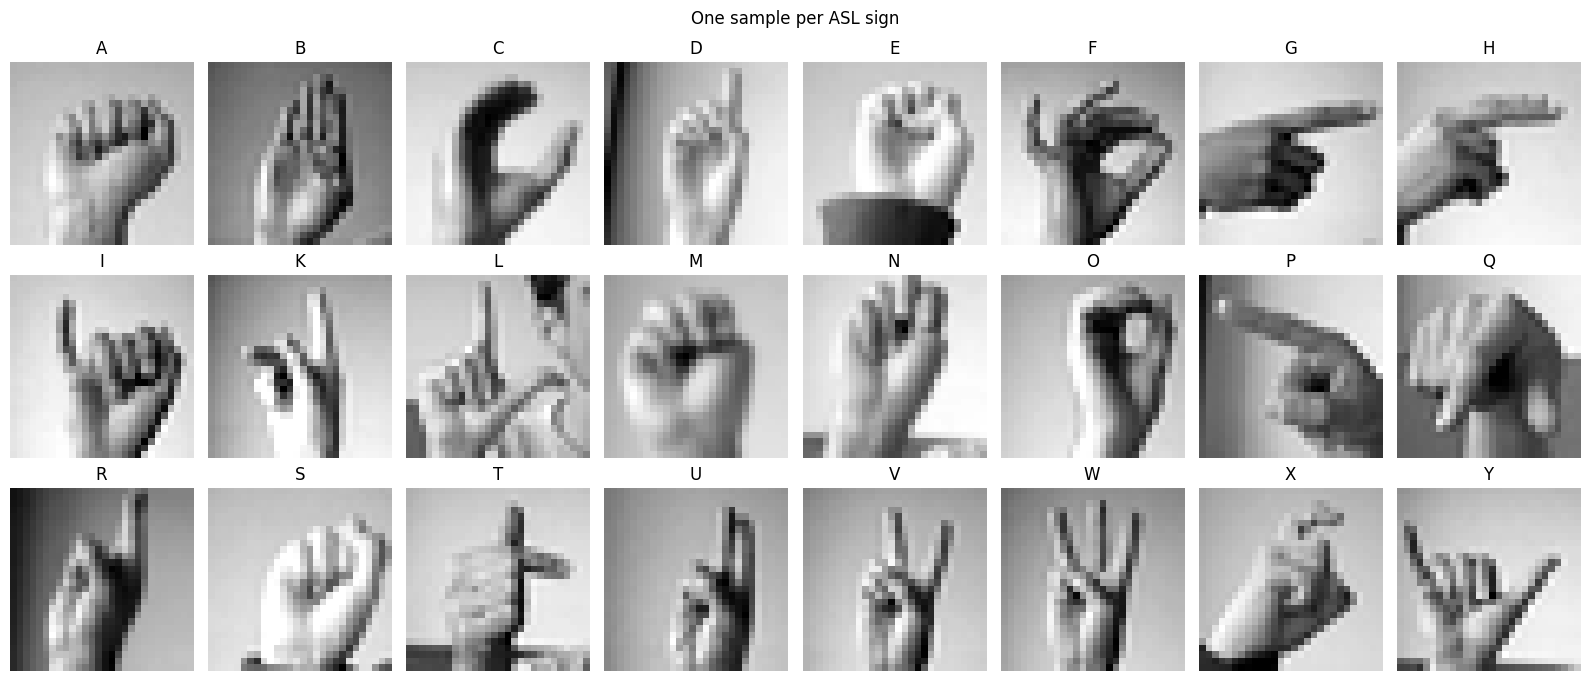

In [ ]:
unique_labels = np.unique(y_train.argmax(axis = 1))

fig, axes = plt.subplots(3, 8, figsize = (16, 7))
axes = axes.flatten()

for i, class_name_char in enumerate(class_names):
  # Determine the actual numeric label value corresponding to the i-th class_name
  actual_label_value = i
  if i >= 9: # Account for the skipped 'J' (label 9)
    actual_label_value += 1

  sample = np.where(y_train.argmax(axis = 1) == actual_label_value)[0][0]
  axes[i].imshow(x_train[sample].squeeze(), cmap = 'gray')
  axes[i].set_title(class_name_char)
  axes[i].axis('off')

plt.suptitle("One sample per ASL sign")
plt.tight_layout()
plt.show()